In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [27]:
df = pd.read_csv('data/stud.csv')

In [28]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [29]:
X=df.drop(columns='math_score')

In [30]:
X.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88


In [31]:
y = df['math_score']

In [32]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [33]:
print("Categories in 'gender' variable:     ",end=" " )
print(list(df['gender'].unique()))

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(list(df['race_ethnicity'].unique()))

print("Categories in'parental level of education' variable:",end=" " )
print(list(df['parental_level_of_education'].unique()))

print("Categories in 'lunch' variable:     ",end=" " )
print(list(df['lunch'].unique()))

print("Categories in 'test preparation course' variable:     ",end=" " )
print(list(df['test_preparation_course'].unique()))

Categories in 'gender' variable:      ['female', 'male']
Categories in 'race_ethnicity' variable:   ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in'parental level of education' variable: ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in 'lunch' variable:      ['standard', 'free/reduced']
Categories in 'test preparation course' variable:      ['none', 'completed']


In [34]:
num_feat = X.select_dtypes(include='int').columns
cat_feat = X.select_dtypes(include='str').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

onehot = OneHotEncoder()
scaler = StandardScaler()

transformer = ColumnTransformer(
    [('onehot', onehot, cat_feat),
    ('scaler', scaler, num_feat),]
)


In [35]:
X = transformer.fit_transform(X)

In [37]:
X.shape

(1000, 19)

In [38]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=21)

In [39]:
X_train

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.46810467,  0.12812699],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
         0.67368424,  0.45733301],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.46810467,  0.52317422],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
        -0.76537273, -1.05701471],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
         0.74221076,  0.52317422],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.01631685,  0.78653904]], shape=(800, 19))

In [40]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [41]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.2564
- Mean Absolute Error: 4.1882
- R2 Score: 0.8811
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.6131
- Mean Absolute Error: 4.5008
- R2 Score: 0.8554


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5244
- Mean Absolute Error: 5.1385
- R2 Score: 0.8169
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.4524
- Mean Absolute Error: 5.1328
- R2 Score: 0.8089


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.2566
- Mean Absolute Error: 4.1873
- R2 Score: 0.8811
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.6070
- Mean Absolute Error: 4.4947
- R2 Score: 0.8557


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7923
- Mean Absolute Error: 4.6270
- R2 Score: 0.8557
-----------------------

In [49]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Models','Score']).sort_values(by=['Score'],ascending=False)

,Models,Score
2,Ridge,0.855721
0,Linear Regression,0.855409
7,CatBoosting Regressor,0.832755
5,Random Forest Regressor,0.823424
8,AdaBoost Regressor,0.812630
1,Lasso,0.808932
6,XGBRegressor,0.793972
3,K-Neighbors Regressor,0.754387
4,Decision Tree,0.671847


In [72]:
linear = LinearRegression(fit_intercept=True)
linear.fit(X_train,y_train)
linear_y_pred = linear.predict(X_test)
score = r2_score(y_test,linear_y_pred)*100
print(score)

85.5409161013607


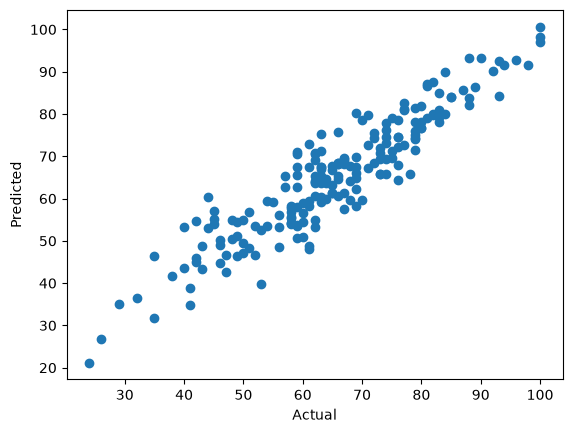

In [64]:
plt.scatter(y_test,linear_y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

<Axes: xlabel='math_score'>

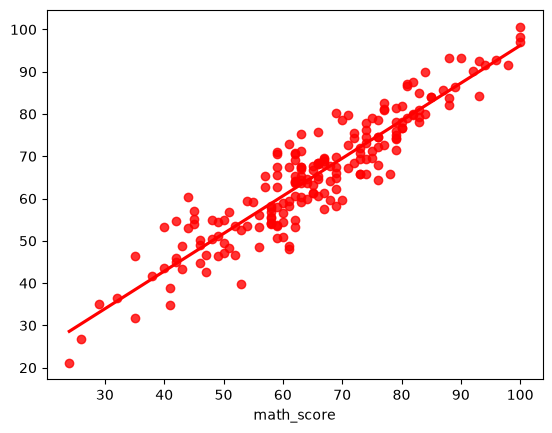

In [70]:
sns.regplot(x=y_test,y=linear_y_pred,ci=None,color='red')